<a href="https://colab.research.google.com/github/megustaSzy/Natural-Language-Processing/blob/main/NLTK_Workshop_4_Raditya_Ahmad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Semantic Analysis and Word
Vectors Using spaCy

In [ ]:
import spacy

try:
    nlp = spacy.load("en_core_web_md")
except OSError:
    print("Downloading spaCy model 'en_core_web_md'...")
    spacy.cli.download("en_core_web_md")
    nlp = spacy.load("en_core_web_md")

utt1 = nlp("I ate a banana.")

In [ ]:
import en_core_web_md
nlp = en_core_web_md.load()

In [ ]:
utt1[3].vector

array([-0.6334   ,  0.18981  , -0.53544  , -0.52658  , -0.30001  ,
        0.30559  , -0.49303  ,  0.14636  ,  0.012273 ,  0.96802  ,
        0.0040354,  0.25234  , -0.29864  , -0.014646 , -0.24905  ,
       -0.67125  , -0.053366 ,  0.59426  , -0.068034 ,  0.10315  ,
        0.66759  ,  0.024617 , -0.37548  ,  0.52557  ,  0.054449 ,
       -0.36748  , -0.28013  ,  0.090898 , -0.025687 , -0.5947   ,
       -0.24269  ,  0.28603  ,  0.686    ,  0.29737  ,  0.30422  ,
        0.69032  ,  0.042784 ,  0.023701 , -0.57165  ,  0.70581  ,
       -0.20813  , -0.03204  , -0.12494  , -0.42933  ,  0.31271  ,
        0.30352  ,  0.09421  , -0.15493  ,  0.071356 ,  0.15022  ,
       -0.41792  ,  0.066394 , -0.034546 , -0.45772  ,  0.57177  ,
       -0.82755  , -0.27885  ,  0.71801  , -0.12425  ,  0.18551  ,
        0.41342  , -0.53997  ,  0.55864  , -0.015805 , -0.1074   ,
       -0.29981  , -0.17271  ,  0.27066  ,  0.043996 ,  0.60107  ,
       -0.353    ,  0.6831   ,  0.20703  ,  0.12068  ,  0.2485

In [ ]:
type(utt1[3].vector)

numpy.ndarray

In [ ]:
utt1[3].vector.shape

(300,)

In [ ]:
utt2 = nlp("I lke a banana,")
utt2.vector
utt2[1:3].vector

array([-6.04094982e-01, -6.39050007e-02, -2.95554996e-01, -1.56675011e-01,
       -6.08840026e-02,  1.51969999e-01,  5.31714976e-01, -4.34305012e-01,
       -2.20555007e-01,  7.42614985e-01,  8.42920020e-02, -2.75000930e-04,
       -3.85213494e-01, -1.98530003e-01,  4.83800024e-02, -1.46623001e-01,
       -2.67134994e-01,  1.10199988e-01, -1.37099996e-02, -1.78863496e-01,
       -2.28840500e-01, -2.14264005e-01, -2.66030014e-01, -5.77655017e-01,
        1.20609999e-01,  3.42104994e-02,  7.32855052e-02, -2.66371518e-01,
        9.45224985e-02, -3.54934990e-01,  2.69550011e-02, -1.07519999e-01,
        3.07720006e-02,  5.67750037e-02,  4.96950001e-02,  1.41460493e-01,
        6.13746494e-02, -1.27821952e-01, -1.60484493e-01,  2.14399993e-02,
       -2.38670006e-01, -1.57272503e-01,  1.01746500e-01,  1.95345998e-01,
        1.73572004e-01, -2.00438499e-01, -6.51209950e-02, -1.32155001e-01,
       -1.71699971e-02,  4.13336992e-01, -2.99769998e-01,  2.69995660e-01,
       -4.28000093e-03, -

In [ ]:
utt3 = nlp("You went there afsksd.")

In [ ]:
for token in utt3:
  print("Token is:",token,"OOV:",token.is_oov,"Token has vector.",token.has_vector)

Token is: You OOV: False Token has vector. True
Token is: went OOV: False Token has vector. True
Token is: there OOV: False Token has vector. True
Token is: afsksd OOV: True Token has vector. False
Token is: . OOV: False Token has vector. True


In [ ]:
utt4 = nlp("I visited England.")
utt5 = nlp("I went to London.")
utt4[1:3].similarity(utt5[1:4])

0.5405576825141907

In [ ]:
utt4[2]

England

In [ ]:
utt4[2].similarity(utt5[3])

0.5125733017921448

In [ ]:
utt4.similarity(utt5)

0.8462151885032654

In [ ]:
utt4.similarity(utt4)

1.0

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import spacy

nlp = spacy.load("en_core_web_md")

vocab = nlp("cat dog tiger elephant monkey lion cheetah burger pizza food cheese wine salad noodles macaroni fruit vegetable")

words = [word.text for word in vocab]

In [ ]:
vecs = np.vstack([word.vector for word in vocab if word.has_vector])

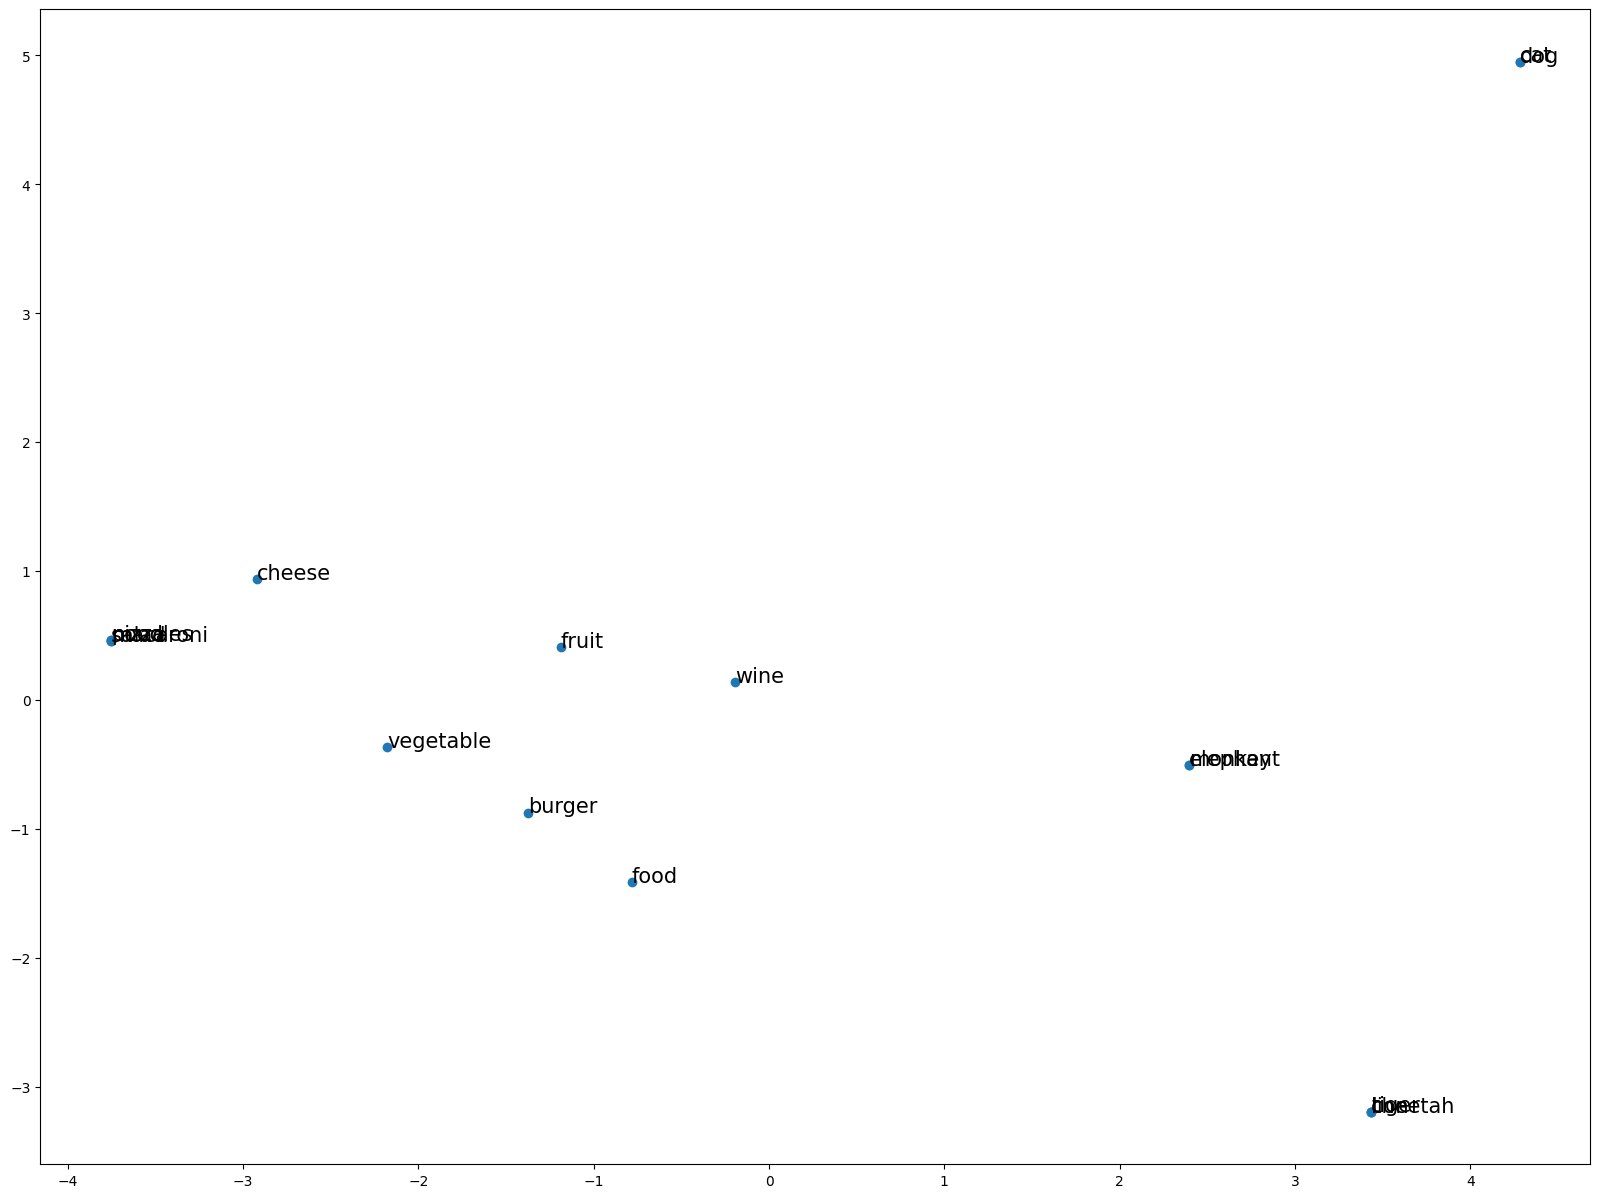

In [ ]:
pca = PCA(n_components=2)
vecs_transformed = pca.fit_transform(vecs)
plt.figure(figsize=(20,15))
plt.scatter(vecs_transformed[:,0], vecs_transformed[:,1])
for word, coord in zip(words, vecs_transformed):
  x,y = coord
  plt.text(x,y,word, size=15)
plt.show()

In [ ]:
utt6 = nlp("I purchased a science fiction book last week. I loved evertyhing related to this fragrance: light, floral, feminine... I purchased a bottle of wine. ")
key = nlp("perfume")
for utt in utt6.sents:
  print(utt.similarity(key))

0.22991575300693512
0.3682955503463745
0.2966938018798828


In [ ]:
utt7 = nlp("My beatiful and cute jumped over the fence")

In [ ]:
utt7.noun_chunks

In [ ]:
list(utt7.noun_chunks)

[the fence]

In [ ]:
for utt in utt7.sents:
  nchunks = [nchunk.text for nchunk in utt.noun_chunks]
  nchunk_utt = nlp ("".join(nchunks))
  print(nchunk_utt.similarity(key))

0.12299991399049759


In [ ]:
utt8 = nlp( """Google Search, often referred as Google, is the most popular
search engine nowadays. It answers a huge volume of queries every day.""" )
utt9 = nlp( """Microsoft Bing is another popular search engine. Microsoft is
known by its star product Microsoft Windows, a popular operating system
sold over the world.""" )
utt10 = nlp( """The Dead Sea is the lowest lake in the world, located in the
Jordan Valley of Israel. It is also the saltiest lake in the world.""" )

In [ ]:
utt8.ents

(Google Search, Google)

In [ ]:
utt9.ents

(Microsoft Bing, Microsoft, Microsoft, Windows)

In [ ]:
utt10.ents

(Jordan Valley, Israel)

In [ ]:
ents1 = [ent.text for ent in utt8.ents]
ents2 = [ent.text for ent in utt9.ents]
ents3 = [ent.text for ent in utt10.ents]
ents1 = nlp("".join(ents1))
ents2 = nlp("".join(ents2))
ents3 = nlp("".join(ents3))

In [ ]:
ents1.similarity(ents2)

0.32126665115356445

In [ ]:
ents1.similarity(ents3)

0.21567876636981964

In [ ]:
ents2.similarity(ents3)

0.2337401658296585